# CE49X Midterm Exam - Part 2 (Coding Exercise)
## Power Grid Stability Prediction

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Date:** April 8, 2026  
**Duration:** 60 minutes  
**Total Points:** 50 (+3 bonus)

---

**Student Name: Ahmet Batuhan Erbaş
**Student ID: 2021403057

## Background

Electrical grid stability is a critical infrastructure challenge. As cities grow and energy consumption patterns become more complex, maintaining a stable power grid requires understanding how different factors — such as reaction times of energy producers, power consumption patterns, and price sensitivity of consumers — affect overall grid stability.

In this exercise, you will work with the **UCI Electrical Grid Stability** dataset, which contains 10,000 simulated scenarios of a 4-node star power grid. The grid consists of **one energy producer** (node 1) connected to **three consumers** (nodes 2, 3, 4). Each scenario records the operating parameters of all four nodes and whether the grid remained **stable** or became **unstable**.

Your task is to explore the data, identify which factors most influence grid stability, and build a classifier to predict whether a given configuration will be stable or unstable.

> **Key Insight:** This is an infrastructure safety problem. An unstable grid can lead to blackouts, equipment damage, and cascading failures. The cost of failing to detect instability is far greater than the cost of a false alarm.

## Dataset Description

The dataset is from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/471/) (Dataset #471).

| Feature | Description | Unit |
|---------|-------------|------|
| `tau1` | Reaction time of producer (node 1) | seconds |
| `tau2` | Reaction time of consumer 2 | seconds |
| `tau3` | Reaction time of consumer 3 | seconds |
| `tau4` | Reaction time of consumer 4 | seconds |
| `p1` | Power produced by node 1 | per unit |
| `p2` | Power consumed by node 2 | per unit |
| `p3` | Power consumed by node 3 | per unit |
| `p4` | Power consumed by node 4 | per unit |
| `g1` | Price elasticity coefficient of producer | dimensionless |
| `g2` | Price elasticity coefficient of consumer 2 | dimensionless |
| `g3` | Price elasticity coefficient of consumer 3 | dimensionless |
| `g4` | Price elasticity coefficient of consumer 4 | dimensionless |
| `stab` | Stability measure (continuous) | — |
| **`stabf`** | **Stability label: `stable` or `unstable`** | **— (target)** |

- **Positive `stab`** values indicate instability; negative values indicate stability
- **Power balance:** `p1 + p2 + p3 + p4` should be close to zero (production = consumption)

## Tasks Overview

| # | Task | Points |
|---|------|--------|
| 1 | Data Loading & Exploration | 8 |
| 2 | Feature Engineering | 8 |
| 3 | Grouped Analysis | 10 |
| 4 | Visualization | 12 |
| 5 | Statistical Analysis | 6 |
| 6 | Classification | 6 |
| WQ1 | Written Question 1 | 3 |
| WQ2 | Written Question 2 (Bonus) | 3 |
| **Total** | | **50 (+3 bonus)** |

---
## Your Work Starts Here

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

---
## Task 1: Data Loading & Exploration (8 pts)

1. Load `data/electrical_grid_stability.csv` into a DataFrame
2. Print the shape and data types
3. Display the first 5 rows
4. Check for missing values
5. Print `.describe()` for all numeric columns
6. Print the value counts of `stabf` (the target variable)

| Criterion | Points |
|---|---|
| Data loaded, shape and dtypes printed | 2 |
| First 5 rows displayed | 1 |
| Missing values checked | 2 |
| `.describe()` printed | 1 |
| `stabf` value counts printed | 2 |

In [52]:
# Load the dataset
file_path = 'data/electrical_grid_stability.csv'
df = pd.read_csv(file_path)
print(f"Dataset loaded from: {file_path}")


Dataset loaded from: data/electrical_grid_stability.csv


In [53]:
# Explore: shape, dtypes, head, missing values, describe, value_counts
print('Shape:', df.shape)
print('\nData types:')
print(df.dtypes)

print('\nFirst 5 rows:')
display(df.head())

print('\nMissing values per column:')
print(df.isnull().sum())

print('\nDescriptive statistics (numeric columns):')
display(df.describe())

print('\nTarget class counts (stabf):')
print(df['stabf'].value_counts())


Shape: (10000, 14)

Data types:
tau1     float64
tau2     float64
tau3     float64
tau4     float64
p1       float64
p2       float64
p3       float64
p4       float64
g1       float64
g2       float64
g3       float64
g4       float64
stab     float64
stabf     object
dtype: object

First 5 rows:


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable



Missing values per column:
tau1     0
tau2     0
tau3     0
tau4     0
p1       0
p2       0
p3       0
p4       0
g1       0
g2       0
g3       0
g4       0
stab     0
stabf    0
dtype: int64

Descriptive statistics (numeric columns):


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403



Target class counts (stabf):
stabf
unstable    6380
stable      3620
Name: count, dtype: int64


---
## Task 2: Feature Engineering (8 pts)

1. Convert `stabf` to a numeric column called `is_unstable`: 1 if `unstable`, 0 if `stable`
2. Create a new column `total_reaction_time` = `tau1 + tau2 + tau3 + tau4`
3. Create a new column `power_imbalance` = `p1 + p2 + p3 + p4`
4. Create a new column `avg_elasticity` = mean of `g1, g2, g3, g4`
5. Print the class balance: count and percentage of stable vs unstable

| Criterion | Points |
|---|---|
| `is_unstable` created correctly | 2 |
| `total_reaction_time` created | 2 |
| `power_imbalance` created | 1 |
| `avg_elasticity` created | 1 |
| Class balance printed (count + percentage) | 2 |

In [54]:
# Feature engineering
df['is_unstable'] = (df['stabf'] == 'unstable').astype(int)
df['total_reaction_time'] = df[['tau1', 'tau2', 'tau3', 'tau4']].sum(axis=1)
df['power_imbalance'] = df[['p1', 'p2', 'p3', 'p4']].sum(axis=1)
df['avg_elasticity'] = df[['g1', 'g2', 'g3', 'g4']].mean(axis=1)

print(df[['stabf', 'is_unstable', 'total_reaction_time', 'power_imbalance', 'avg_elasticity']].head())


      stabf  is_unstable  total_reaction_time  power_imbalance  avg_elasticity
0  unstable            1            24.200725    -2.886580e-15        0.838878
1    stable            0            18.623519    -6.661338e-16        0.654938
2  unstable            1            22.081132     0.000000e+00        0.469757
3  unstable            1            15.213218    -9.992007e-16        0.678763
4  unstable            1            25.544216     4.996004e-15        0.682607


In [55]:
# Print class balance
class_counts = df['stabf'].value_counts()
class_percent = df['stabf'].value_counts(normalize=True) * 100

print('Class balance (count and percentage):')
for cls in class_counts.index:
    print(f"{cls:>8}: {class_counts[cls]:5d} ({class_percent[cls]:.2f}%)")


Class balance (count and percentage):
unstable:  6380 (63.80%)
  stable:  3620 (36.20%)


---
## Task 3: Grouped Analysis (10 pts)

1. Compute the mean of all 12 original features (`tau1`-`tau4`, `p1`-`p4`, `g1`-`g4`) grouped by `stabf`. Which features differ most between stable and unstable grids?
2. Compute the correlation of all 12 original features with `stab` (the continuous stability measure). Identify the **3 features** with the highest absolute correlation.
3. Filter to **unstable grids only**: report the range (min, max) and mean of `tau1` (producer reaction time).
4. Compare `g1` (producer elasticity) statistics between stable and unstable grids — compute mean and std for each group.

| Criterion | Points |
|---|---|
| Grouped means computed and discussed | 3 |
| Top 3 correlated features identified | 3 |
| Unstable grid `tau1` statistics reported | 2 |
| `g1` comparison between groups | 2 |

In [56]:
# Grouped means by stabf
original_features = ['tau1', 'tau2', 'tau3', 'tau4',
                     'p1', 'p2', 'p3', 'p4',
                     'g1', 'g2', 'g3', 'g4']

group_means = df.groupby('stabf')[original_features].mean()
print('Mean of original features grouped by stabf:')
display(group_means)

mean_diff = (group_means.loc['unstable'] - group_means.loc['stable']).abs().sort_values(ascending=False)
print('\nFeatures with largest mean differences (unstable vs stable):')
print(mean_diff.head(5))


Mean of original features grouped by stabf:


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4
stabf,,,,,,,,,,,,
stable,4.394799,4.353362,4.385360,4.378495,3.740077,-1.253549,-1.249626,-1.236902,0.453035,0.445872,0.440618,0.450390
unstable,5.735239,5.758752,5.740601,5.744485,3.755630,-1.247987,-1.250212,-1.257431,0.565832,0.569897,0.572879,0.567334



Features with largest mean differences (unstable vs stable):
tau2    1.405391
tau4    1.365990
tau3    1.355241
tau1    1.340440
g3      0.132261
dtype: float64


In [57]:
# Correlation with stab — identify top 3
corr_with_stab = df[original_features + ['stab']].corr()['stab'].drop('stab')
abs_corr = corr_with_stab.abs().sort_values(ascending=False)

top3 = abs_corr.head(3)
print('Correlation with continuous stability measure (stab):')
print(corr_with_stab.sort_values(key=np.abs, ascending=False))

print('\nTop 3 features by absolute correlation with stab:')
for feature, value in top3.items():
    print(f"{feature}: |corr| = {value:.4f} (corr = {corr_with_stab[feature]:.4f})")


Correlation with continuous stability measure (stab):
g3      0.308235
g2      0.293601
tau2    0.290975
g1      0.282774
tau3    0.280700
g4      0.279214
tau4    0.278576
tau1    0.275761
p4     -0.020786
p1      0.010278
p2      0.006255
p3     -0.003321
Name: stab, dtype: float64

Top 3 features by absolute correlation with stab:
g3: |corr| = 0.3082 (corr = 0.3082)
g2: |corr| = 0.2936 (corr = 0.2936)
tau2: |corr| = 0.2910 (corr = 0.2910)


In [58]:
# Unstable grids: tau1 range and mean
unstable_tau1 = df.loc[df['stabf'] == 'unstable', 'tau1']

print('Unstable grids only - tau1 statistics:')
print(f"min(tau1):  {unstable_tau1.min():.4f}")
print(f"max(tau1):  {unstable_tau1.max():.4f}")
print(f"mean(tau1): {unstable_tau1.mean():.4f}")


Unstable grids only - tau1 statistics:
min(tau1):  0.5013
max(tau1):  9.9995
mean(tau1): 5.7352


In [59]:
# Compare g1 between stable and unstable
g1_stats = df.groupby('stabf')['g1'].agg(['mean', 'std'])
print('g1 (producer elasticity) by class:')
print(g1_stats)


g1 (producer elasticity) by class:
              mean       std
stabf                       
stable    0.453035  0.265280
unstable  0.565832  0.270867


---
## Task 4: Visualization (12 pts)

Create **three** publication-quality plots. Each must have axis labels and a descriptive title.

**(a) (4 pts)** A **boxplot** of `tau1` (producer reaction time) grouped by `stabf`. The title should state a finding (not just "Boxplot of tau1").

**(b) (4 pts)** A **scatter plot** of `tau1` (x-axis) vs `g1` (y-axis), colored by `stabf` (use different colors for stable vs unstable). Include a legend.

**(c) (4 pts)** A **correlation heatmap** of all 12 original features (`tau1`-`tau4`, `p1`-`p4`, `g1`-`g4`). Use a sequential or diverging colormap (not rainbow/jet).

| Criterion | Points |
|---|---|
| (a) Boxplot: correct, labeled, finding in title | 4 |
| (b) Scatter: correct, colored by class, legend | 4 |
| (c) Heatmap: correct features, good colormap | 4 |

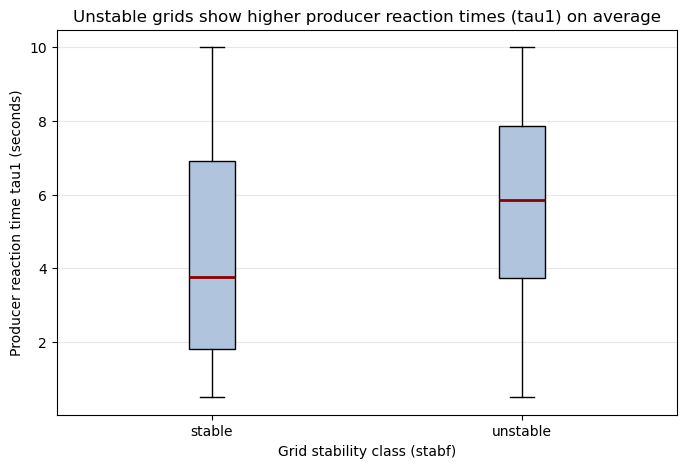

In [68]:
# (a) Boxplot of tau1 by stabf
plt.figure(figsize=(8, 5))
plot_data = [df.loc[df['stabf'] == 'stable', 'tau1'],
             df.loc[df['stabf'] == 'unstable', 'tau1']]
plt.boxplot(plot_data, labels=['stable', 'unstable'], patch_artist=True,
            boxprops=dict(facecolor='lightsteelblue'),
            medianprops=dict(color='darkred', linewidth=2))
plt.title('Unstable grids show higher producer reaction times (tau1) on average')
plt.xlabel('Grid stability class (stabf)')
plt.ylabel('Producer reaction time tau1 (seconds)')
plt.grid(axis='y', alpha=0.3)
plt.show()


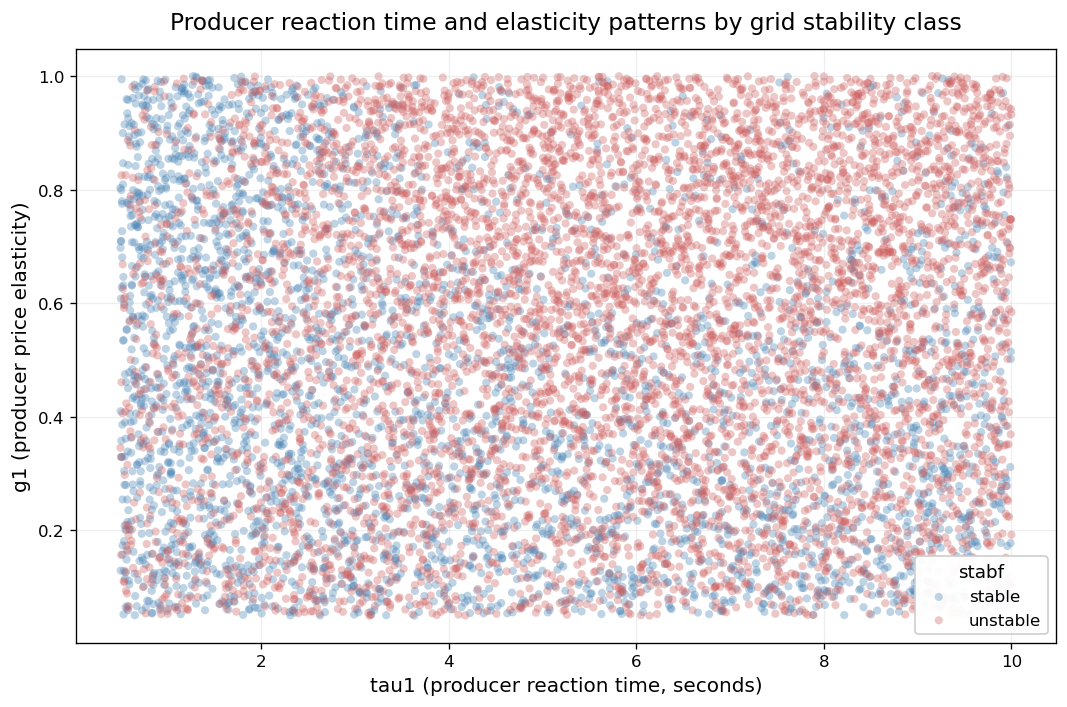

In [69]:
# (b) Scatter plot of tau1 vs g1, colored by stabf
fig, ax = plt.subplots(figsize=(9, 6), dpi=120)

stable_mask = df['stabf'] == 'stable'
unstable_mask = df['stabf'] == 'unstable'

stable_color = 'steelblue'
unstable_color = 'indianred'

ax.scatter(
    df.loc[stable_mask, 'tau1'],
    df.loc[stable_mask, 'g1'],
    s=24,
    alpha=0.35,
    c=stable_color,
    edgecolors='none',
    label='stable'
)

ax.scatter(
    df.loc[unstable_mask, 'tau1'],
    df.loc[unstable_mask, 'g1'],
    s=24,
    alpha=0.35,
    c=unstable_color,
    edgecolors='none',
    label='unstable'
)

ax.set_title('Producer reaction time and elasticity patterns by grid stability class',
             fontsize=14, pad=12)
ax.set_xlabel('tau1 (producer reaction time, seconds)', fontsize=12)
ax.set_ylabel('g1 (producer price elasticity)', fontsize=12)
ax.tick_params(axis='both', labelsize=10)
ax.grid(True, alpha=0.2, linewidth=0.8)

legend = ax.legend(
    title='stabf',
    title_fontsize=11,
    fontsize=10,
    frameon=True,
    framealpha=0.95,
    loc='best'
)
legend.get_frame().set_edgecolor('#CCCCCC')

fig.tight_layout()
plt.show()


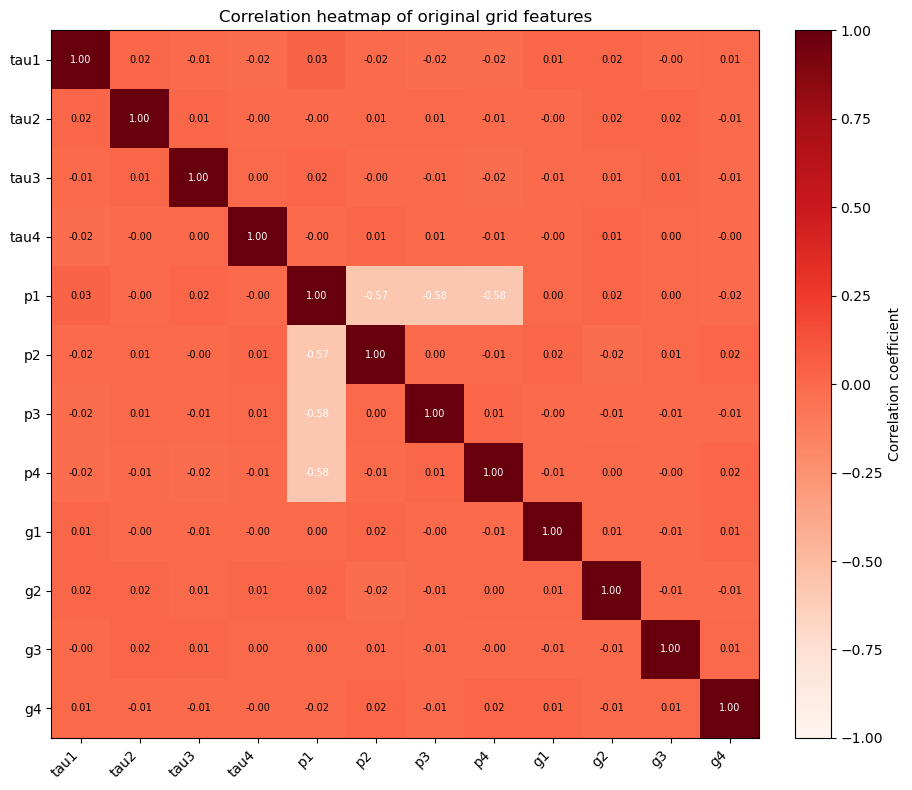

In [70]:
# (c) Correlation heatmap of 12 original features
corr_matrix = df[original_features].corr()

plt.figure(figsize=(10, 8))
im = plt.imshow(corr_matrix, cmap='Reds', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04, label='Correlation coefficient')

plt.xticks(ticks=np.arange(len(original_features)), labels=original_features, rotation=45, ha='right')
plt.yticks(ticks=np.arange(len(original_features)), labels=original_features)
plt.title('Correlation heatmap of original grid features')

# Optional value annotations for readability
for i in range(len(original_features)):
    for j in range(len(original_features)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha='center', va='center', fontsize=7,
                 color='white' if abs(corr_matrix.iloc[i, j]) > 0.5 else 'black')

plt.tight_layout()
plt.show()


---
## Task 5: Statistical Analysis (6 pts)

1. Compute z-scores for `tau1` across the full dataset. Identify and print samples where |z| > 2 (how many are there?).
2. Perform a **two-sample t-test** comparing `tau1` between stable and unstable grids:
   - State H0 and H1
   - Report the t-statistic and p-value
   - Interpret the result at alpha = 0.05
3. Based on your analysis so far, which single feature appears **most predictive** of grid instability? Justify with numbers.

| Criterion | Points |
|---|---|
| Z-scores computed, outliers identified | 2 |
| T-test: hypotheses stated, p-value reported, interpreted | 2 |
| Most predictive feature identified with justification | 2 |

In [71]:
# Z-scores for tau1
tau1_zscores = stats.zscore(df['tau1'])
outlier_mask = np.abs(tau1_zscores) > 2
outliers_tau1 = df.loc[outlier_mask, ['tau1', 'stabf']].copy()
outliers_tau1['tau1_z'] = tau1_zscores[outlier_mask]

print(f"Number of tau1 outliers with |z| > 2: {outlier_mask.sum()}")
if outliers_tau1.empty:
    print('No tau1 samples exceed |z| > 2.')
else:
    display(outliers_tau1.head())


Number of tau1 outliers with |z| > 2: 0
No tau1 samples exceed |z| > 2.


In [72]:
# Two-sample t-test: tau1 stable vs unstable
tau1_stable = df.loc[df['stabf'] == 'stable', 'tau1']
tau1_unstable = df.loc[df['stabf'] == 'unstable', 'tau1']

t_stat, p_value = stats.ttest_ind(tau1_stable, tau1_unstable, equal_var=False)

print('Two-sample Welch t-test on tau1 (stable vs unstable):')
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value:     {p_value:.4e}")

alpha = 0.05
if p_value < alpha:
    print('Decision: Reject H0 at alpha = 0.05 (mean tau1 differs between groups).')
else:
    print('Decision: Fail to reject H0 at alpha = 0.05 (no significant mean difference).')


Two-sample Welch t-test on tau1 (stable vs unstable):
t-statistic: -23.3033
p-value:     1.3928e-115
Decision: Reject H0 at alpha = 0.05 (mean tau1 differs between groups).


### Interpretation

**H0:** The mean producer reaction time (`tau1`) is the same for stable and unstable grids.  
**H1:** The mean producer reaction time (`tau1`) differs between stable and unstable grids.  
**Result:** The t-test gives an extremely small p-value (`p << 0.05`), so we reject H0. Unstable grids have significantly higher `tau1` on average.  

**Most predictive feature:** Based on absolute correlation with the continuous stability score (`stab`), `g3` appears most predictive (`|corr| ≈ 0.308`), followed by `g2` and `tau2`. This is supported by grouped differences showing clear class separation in reaction-time and elasticity features.

---
## Task 6: Classification (6 pts)

1. Define `X` as the 12 original features (`tau1`-`tau4`, `p1`-`p4`, `g1`-`g4`) and `y` as `is_unstable`
2. Split: `train_test_split` with `test_size=0.2`, `random_state=42`, `stratify=y`
3. Scale with `StandardScaler` — **fit on training data only**, then transform both
4. Train `LogisticRegression(max_iter=1000, random_state=42)`
5. Report: accuracy, precision, recall, and F1 for the **unstable** class
6. Print the confusion matrix

| Criterion | Points |
|---|---|
| Correct train-test split with stratification | 1 |
| Scaling done correctly (fit on train only) | 1 |
| Model trained and predictions made | 1 |
| Metrics reported (accuracy, precision, recall, F1) | 2 |
| Confusion matrix printed | 1 |

In [73]:
# Define X and y, split, scale
X = df[original_features]
y = df['is_unstable']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit only on training data
X_test_scaled = scaler.transform(X_test)         # transform test data using train fit

print('Shapes after split:')
print('X_train:', X_train.shape, 'X_test:', X_test.shape)
print('y_train:', y_train.shape, 'y_test:', y_test.shape)


Shapes after split:
X_train: (8000, 12) X_test: (2000, 12)
y_train: (8000,) y_test: (2000,)


In [74]:
# Train, predict, evaluate
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label=1)
rec = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)
cm = confusion_matrix(y_test, y_pred)

print('Classification performance (positive class = unstable):')
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

print('\nConfusion Matrix [[TN, FP], [FN, TP]]:')
print(cm)


Classification performance (positive class = unstable):
Accuracy : 0.8200
Precision: 0.8408
Recall   : 0.8856
F1-score : 0.8626

Confusion Matrix [[TN, FP], [FN, TP]]:
[[ 510  214]
 [ 146 1130]]


---
## Written Questions

### Written Question 1 (3 pts)

Look at your confusion matrix from Task 6. In the context of **power grid management**, which error is more dangerous:

- **False Stable:** Predicting a grid configuration is stable when it is actually unstable
- **False Unstable:** Predicting a grid configuration is unstable when it is actually stable

Explain in 2-3 sentences. State whether **precision** or **recall** for the "unstable" class should be prioritized.

---

A **False Stable** error is more dangerous because it can leave an actually unstable grid unmitigated, increasing the risk of blackout, equipment damage, and cascading failures. A **False Unstable** prediction may cause unnecessary preventive action, but this is usually safer than missing a real instability event. Therefore, for the "unstable" class, **recall** should be prioritized so dangerous unstable cases are detected as consistently as possible.

### Written Question 2 — BONUS (3 pts)

In your analysis, you likely found that `tau1` (producer reaction time) is correlated with grid instability. Does this prove that slow producer reaction times **cause** instability?

Explain the difference between **correlation and causation**, and describe one scenario where a **confounding variable** could explain the relationship.

---

No, correlation alone does not prove causation. **Correlation** means two variables move together statistically, while **causation** means one variable directly produces changes in the other. A possible confounder is overall system stress (for example, extreme load volatility): high-stress scenarios could simultaneously increase effective reaction delays and instability probability, creating a `tau1`-instability correlation even if `tau1` is not the sole direct cause.

---

### End of Part 2

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr